## Imports

In [1]:
from __future__ import annotations

import time

from copy import deepcopy
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import xgboost as xgb

from mlflow.models import infer_signature
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

from walmart_forecasting.data import (
    load_merged_data,
)
from walmart_forecasting.experiment import (
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
    save_architecture_result,
)
from walmart_forecasting.features import (
    add_basic_features,
    add_exact_lag_features,
)
from walmart_forecasting.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    weighted_mae,
)
from walmart_forecasting.preprocessing import (
    build_tree_preprocessor,
)
from walmart_forecasting.tracking import (
    mlflow_run,
)
from walmart_forecasting.validation import (
    competition_like_holdout,
    expanding_window_splits,
)


pd.set_option(
    "display.max_columns",
    100,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

print(
    "XGBoost version:",
    xgb.__version__,
)

XGBoost version: 3.3.0


## Configuration

In [2]:
ARCHITECTURE = "xgboost"
EXPERIMENT_NAME = "XGBoost_Training"

HOLIDAY_WEIGHT = 5.0
NON_HOLIDAY_WEIGHT = 1.0

EARLY_STOPPING_ROUNDS = 100

BASE_PARAMETERS = {
    "n_estimators": 3000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5.0,
    "gamma": 0.0,
    "subsample": 0.90,
    "colsample_bytree": 0.90,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}

## Data loading and validation

In [3]:
data = load_merged_data()

train = data.train.copy()
test = data.test.copy()

final_split = competition_like_holdout(
    train_data=train,
    test_data=test,
)

cv_splits = expanding_window_splits(
    data=final_split.train,
    n_splits=CV_FOLDS,
    validation_weeks=CV_VALIDATION_WEEKS,
)

series_count = (
    final_split.train[
        ["Store", "Dept"]
    ]
    .drop_duplicates()
    .shape[0]
)

split_summary = pd.DataFrame(
    [
        {
            "split": f"cv_fold_{fold_number}",
            "train_start": (
                fold.train["Date"].min()
            ),
            "train_end": (
                fold.train["Date"].max()
            ),
            "validation_start": (
                fold.validation["Date"].min()
            ),
            "validation_end": (
                fold.validation["Date"].max()
            ),
            "train_rows": len(fold.train),
            "validation_rows": len(
                fold.validation
            ),
        }
        for fold_number, fold in enumerate(
            cv_splits,
            start=1,
        )
    ]
    + [
        {
            "split": "final_holdout",
            "train_start": (
                final_split.train[
                    "Date"
                ].min()
            ),
            "train_end": (
                final_split.train[
                    "Date"
                ].max()
            ),
            "validation_start": (
                final_split.validation[
                    "Date"
                ].min()
            ),
            "validation_end": (
                final_split.validation[
                    "Date"
                ].max()
            ),
            "train_rows": len(
                final_split.train
            ),
            "validation_rows": len(
                final_split.validation
            ),
        }
    ]
)

split_summary

,split,train_start,train_end,validation_start,validation_end,train_rows,validation_rows
0,cv_fold_1,2010-02-05,2011-04-29,2011-05-06,2011-07-29,190674,38164
1,cv_fold_2,2010-02-05,2011-07-29,2011-08-05,2011-10-28,228838,38346
2,cv_fold_3,2010-02-05,2011-10-28,2011-11-04,2012-01-27,267184,38798
3,final_holdout,2010-02-05,2012-01-27,2012-02-03,2012-10-26,305982,115588


## Feature preparation

In [4]:
def prepare_features(
    rows: pd.DataFrame,
    history: pd.DataFrame,
    lags: tuple[int, ...],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ordered_rows = (
        rows
        .sort_values(
            ["Date", "Store", "Dept"]
        )
        .reset_index(drop=True)
        .copy()
    )

    ordered_rows["_row_order"] = np.arange(
        len(ordered_rows)
    )

    features = add_basic_features(
        ordered_rows
    )

    if lags:
        features = add_exact_lag_features(
            rows=features,
            history=history,
            lags=lags,
        )

        for lag in lags:
            lag_column = f"lag_{lag}"

            features[
                f"{lag_column}_missing"
            ] = (
                features[lag_column]
                .isna()
                .astype("int8")
            )

    features = (
        features
        .sort_values("_row_order")
        .reset_index(drop=True)
    )

    ordered_rows = (
        ordered_rows
        .sort_values("_row_order")
        .drop(columns="_row_order")
        .reset_index(drop=True)
    )

    features = features.drop(
        columns=[
            "_row_order",
            "Weekly_Sales",
            "Date",
        ],
        errors="ignore",
    )

    return ordered_rows, features

In [5]:
def make_sample_weights(
    rows: pd.DataFrame,
) -> np.ndarray:
    return np.where(
        rows["IsHoliday"].astype(bool),
        HOLIDAY_WEIGHT,
        NON_HOLIDAY_WEIGHT,
    ).astype(float)


def evaluate_predictions(
    rows: pd.DataFrame,
    predictions: np.ndarray,
) -> dict[str, float]:
    return {
        "wmae": weighted_mae(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
            is_holiday=rows[
                "IsHoliday"
            ],
        ),
        "mae": mean_absolute_error(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
        ),
        "rmse": root_mean_squared_error(
            y_true=rows[
                "Weekly_Sales"
            ],
            y_pred=predictions,
        ),
    }

## Cross-validation trial runner

In [6]:
def run_cv_trial(
    trial: dict,
) -> tuple[
    dict,
    pd.DataFrame,
    dict[int, dict],
]:
    fold_results = []
    fold_learning_curves = {}

    for fold_number, fold in enumerate(
        cv_splits,
        start=1,
    ):
        train_rows, train_features = (
            prepare_features(
                rows=fold.train,
                history=fold.train,
                lags=trial["lags"],
            )
        )

        validation_rows, validation_features = (
            prepare_features(
                rows=fold.validation,
                history=fold.train,
                lags=trial["lags"],
            )
        )

        extra_numeric_columns = []

        for lag in trial["lags"]:
            extra_numeric_columns.extend(
                [
                    f"lag_{lag}",
                    f"lag_{lag}_missing",
                ]
            )

        preprocessor = (
            build_tree_preprocessor(
                extra_numeric_columns=(
                    extra_numeric_columns
                ),
                include_economic=trial[
                    "include_economic"
                ],
                markdown_strategy=trial[
                    "markdown_strategy"
                ],
            )
        )

        x_train = (
            preprocessor.fit_transform(
                train_features
            )
        )

        x_validation = (
            preprocessor.transform(
                validation_features
            )
        )

        y_train = (
            train_rows[
                "Weekly_Sales"
            ]
            .to_numpy()
        )

        y_validation = (
            validation_rows[
                "Weekly_Sales"
            ]
            .to_numpy()
        )

        train_weights = (
            make_sample_weights(
                train_rows
            )
        )

        validation_weights = (
            make_sample_weights(
                validation_rows
            )
        )

        model = XGBRegressor(
            objective="reg:absoluteerror",
            eval_metric="mae",
            tree_method="hist",
            random_state=(
                DEFAULT_RANDOM_SEED
            ),
            n_jobs=-1,
            verbosity=0,
            importance_type="gain",
            early_stopping_rounds=(
                EARLY_STOPPING_ROUNDS
            ),
            **trial["parameters"],
        )

        fit_start = time.perf_counter()

        model.fit(
            x_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[
                (
                    x_train,
                    y_train,
                ),
                (
                    x_validation,
                    y_validation,
                ),
            ],
            sample_weight_eval_set=[
                train_weights,
                validation_weights,
            ],
            verbose=False,
        )

        fit_seconds = (
            time.perf_counter()
            - fit_start
        )

        raw_best_iteration = getattr(
            model,
            "best_iteration",
            None,
        )

        if raw_best_iteration is None:
            best_n_estimators = int(
                trial["parameters"][
                    "n_estimators"
                ]
            )
        else:
            best_n_estimators = (
                int(raw_best_iteration) + 1
            )

        iteration_range = (
            0,
            best_n_estimators,
        )

        train_predict_start = (
            time.perf_counter()
        )

        train_predictions = (
            model.predict(
                x_train,
                iteration_range=(
                    iteration_range
                ),
            )
        )

        validation_predictions = (
            model.predict(
                x_validation,
                iteration_range=(
                    iteration_range
                ),
            )
        )

        predict_seconds = (
            time.perf_counter()
            - train_predict_start
        )

        train_metrics = (
            evaluate_predictions(
                rows=train_rows,
                predictions=(
                    train_predictions
                ),
            )
        )

        validation_metrics = (
            evaluate_predictions(
                rows=validation_rows,
                predictions=(
                    validation_predictions
                ),
            )
        )

        generalization_gap = (
            validation_metrics["wmae"]
            - train_metrics["wmae"]
        )

        if trial["lags"]:
            lag_coverage = float(
                validation_features[
                    [
                        f"lag_{lag}"
                        for lag in trial[
                            "lags"
                        ]
                    ]
                ]
                .notna()
                .all(axis=1)
                .mean()
            )
        else:
            lag_coverage = None

        fold_results.append(
            {
                "fold": fold_number,
                "train_wmae": (
                    train_metrics["wmae"]
                ),
                "validation_wmae": (
                    validation_metrics[
                        "wmae"
                    ]
                ),
                "generalization_gap": (
                    generalization_gap
                ),
                "validation_mae": (
                    validation_metrics[
                        "mae"
                    ]
                ),
                "validation_rmse": (
                    validation_metrics[
                        "rmse"
                    ]
                ),
                "best_n_estimators": (
                    best_n_estimators
                ),
                "lag_coverage": (
                    lag_coverage
                ),
                "fit_seconds": (
                    fit_seconds
                ),
                "predict_seconds": (
                    predict_seconds
                ),
            }
        )

        fold_learning_curves[
            fold_number
        ] = model.evals_result()

        print(
            f"{trial['trial_id']} | "
            f"fold={fold_number} | "
            f"train WMAE="
            f"{train_metrics['wmae']:,.2f} | "
            f"validation WMAE="
            f"{validation_metrics['wmae']:,.2f} | "
            f"gap="
            f"{generalization_gap:,.2f} | "
            f"trees="
            f"{best_n_estimators}"
        )

    fold_frame = pd.DataFrame(
        fold_results
    )

    summary = {
        "trial_id": trial["trial_id"],
        "trial_name": (
            trial["trial_name"]
        ),
        "capacity_profile": trial[
            "capacity_profile"
        ],
        "feature_set": (
            trial["feature_set"]
        ),
        "preprocessing": (
            trial["preprocessing"]
        ),
        "lags": str(trial["lags"]),
        "include_economic": trial[
            "include_economic"
        ],
        "markdown_strategy": trial[
            "markdown_strategy"
        ],
        "cv_train_wmae_mean": float(
            fold_frame[
                "train_wmae"
            ].mean()
        ),
        "cv_wmae_mean": float(
            fold_frame[
                "validation_wmae"
            ].mean()
        ),
        "cv_wmae_std": float(
            fold_frame[
                "validation_wmae"
            ].std(ddof=0)
        ),
        "cv_generalization_gap_mean": float(
            fold_frame[
                "generalization_gap"
            ].mean()
        ),
        "cv_generalization_gap_std": float(
            fold_frame[
                "generalization_gap"
            ].std(ddof=0)
        ),
        "cv_mae_mean": float(
            fold_frame[
                "validation_mae"
            ].mean()
        ),
        "cv_rmse_mean": float(
            fold_frame[
                "validation_rmse"
            ].mean()
        ),
        "best_n_estimators_median": int(
            np.median(
                fold_frame[
                    "best_n_estimators"
                ]
            )
        ),
        "lag_coverage_mean": (
            float(
                fold_frame[
                    "lag_coverage"
                ].mean()
            )
            if trial["lags"]
            else None
        ),
        "fit_seconds": float(
            fold_frame[
                "fit_seconds"
            ].sum()
        ),
        "predict_seconds": float(
            fold_frame[
                "predict_seconds"
            ].sum()
        ),
    }

    run_name = make_run_name(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        trial_name=trial[
            "trial_name"
        ],
    )

    parameters = build_common_parameters(
        architecture=ARCHITECTURE,
        stage="tuning",
        feature_set=trial[
            "feature_set"
        ],
        preprocessing=trial[
            "preprocessing"
        ],
        evaluation_scope="full_dataset",
        forecast_strategy=(
            "global_tabular"
        ),
        series_count=series_count,
        extra_parameters={
            **trial["parameters"],
            "objective": (
                "reg:absoluteerror"
            ),
            "eval_metric": "mae",
            "tree_method": "hist",
            "lags": list(
                trial["lags"]
            ),
            "include_economic": trial[
                "include_economic"
            ],
            "markdown_strategy": trial[
                "markdown_strategy"
            ],
            "capacity_profile": trial[
                "capacity_profile"
            ],
        },
    )

    logged_metrics = {
        "cv_train_wmae_mean": (
            summary[
                "cv_train_wmae_mean"
            ]
        ),
        "cv_wmae_mean": (
            summary[
                "cv_wmae_mean"
            ]
        ),
        "cv_wmae_std": (
            summary[
                "cv_wmae_std"
            ]
        ),
        "cv_generalization_gap_mean": (
            summary[
                "cv_generalization_gap_mean"
            ]
        ),
        "cv_generalization_gap_std": (
            summary[
                "cv_generalization_gap_std"
            ]
        ),
        "cv_mae_mean": (
            summary["cv_mae_mean"]
        ),
        "cv_rmse_mean": (
            summary["cv_rmse_mean"]
        ),
        "best_n_estimators_median": (
            summary[
                "best_n_estimators_median"
            ]
        ),
        "fit_seconds": (
            summary["fit_seconds"]
        ),
        "predict_seconds": (
            summary["predict_seconds"]
        ),
    }

    if trial["lags"]:
        logged_metrics[
            "lag_coverage_mean"
        ] = summary[
            "lag_coverage_mean"
        ]

    for row in fold_results:
        fold_number = int(
            row["fold"]
        )

        logged_metrics[
            f"fold_{fold_number}_"
            "train_wmae"
        ] = row["train_wmae"]

        logged_metrics[
            f"fold_{fold_number}_wmae"
        ] = row["validation_wmae"]

        logged_metrics[
            f"fold_{fold_number}_"
            "generalization_gap"
        ] = row[
            "generalization_gap"
        ]

        logged_metrics[
            f"fold_{fold_number}_mae"
        ] = row["validation_mae"]

        logged_metrics[
            f"fold_{fold_number}_rmse"
        ] = row["validation_rmse"]

        logged_metrics[
            f"fold_{fold_number}_"
            "best_n_estimators"
        ] = row[
            "best_n_estimators"
        ]

    with mlflow_run(
        experiment_name=EXPERIMENT_NAME,
        run_name=run_name,
        parameters=parameters,
        tags={
            "architecture": (
                ARCHITECTURE
            ),
            "stage": "tuning",
            "scope": "full_dataset",
            "trial_id": trial[
                "trial_id"
            ],
            "capacity_profile": trial[
                "capacity_profile"
            ],
        },
    ):
        mlflow.log_metrics(
            logged_metrics
        )

        mlflow.log_dict(
            {
                "folds": (
                    fold_frame
                    .to_dict(
                        orient="records"
                    )
                )
            },
            "evaluation/fold_metrics.json",
        )

        mlflow.log_dict(
            fold_learning_curves,
            "evaluation/"
            "learning_curves.json",
        )

    return (
        summary,
        fold_frame,
        fold_learning_curves,
    )

# Feature trials

In [7]:
feature_trials = [
    {
        "trial_id": "feature_core",
        "trial_name": "core",
        "capacity_profile": (
            "balanced"
        ),
        "feature_set": (
            "core_calendar_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "economic_median_ohe_v1"
        ),
        "lags": (),
        "include_economic": True,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
    {
        "trial_id": "feature_lag52",
        "trial_name": "lag52",
        "capacity_profile": (
            "balanced"
        ),
        "feature_set": (
            "core_calendar_lag52_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "economic_median_ohe_v1"
        ),
        "lags": (52,),
        "include_economic": True,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
    {
        "trial_id": (
            "feature_lag52_no_economic"
        ),
        "trial_name": (
            "lag52_no_economic"
        ),
        "capacity_profile": (
            "balanced"
        ),
        "feature_set": (
            "core_calendar_lag52_"
            "no_economic_v1"
        ),
        "preprocessing": (
            "tree_markdown_zero_"
            "no_economic_ohe_v1"
        ),
        "lags": (52,),
        "include_economic": False,
        "markdown_strategy": "zero",
        "parameters": deepcopy(
            BASE_PARAMETERS
        ),
    },
]

trial_registry = {
    trial["trial_id"]: trial
    for trial in feature_trials
}

trial_summaries = []
trial_fold_results = {}
trial_learning_curves = {}

In [8]:
for trial in feature_trials:
    (
        summary,
        fold_frame,
        learning_curves,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_learning_curves[
        trial["trial_id"]
    ] = learning_curves

feature_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

feature_results[
    [
        "trial_id",
        "feature_set",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "cv_generalization_gap_mean",
        "best_n_estimators_median",
        "fit_seconds",
    ]
]

feature_core | fold=1 | train WMAE=1,871.74 | validation WMAE=2,205.52 | gap=333.78 | trees=3000
feature_core | fold=2 | train WMAE=1,856.97 | validation WMAE=2,182.73 | gap=325.75 | trees=3000
feature_core | fold=3 | train WMAE=1,834.67 | validation WMAE=3,559.24 | gap=1,724.57 | trees=3000


Accessing as lkhiz23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/09 17:21:21 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Training' does not exist. Creating a new experiment.


...

🏃 View run xgboost__tuning__core_calendar_lag52_v1__lag52__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/b7e9cc88cd8b469cae8db064d5218f2e
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6
feature_lag52_no_economic | fold=1 | train WMAE=3,524.47 | validation WMAE=1,801.90 | gap=-1,722.57 | trees=1165
feature_lag52_no_economic | fold=2 | train WMAE=2,266.00 | validation WMAE=1,562.92 | gap=-703.08 | trees=2432
feature_lag52_no_economic | fold=3 | train WMAE=4,218.27 | validation WMAE=2,912.47 | gap=-1,305.80 | trees=536


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run xgboost__tuning__core_calendar_lag52_no_economic_v1__lag52_no_economic__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/8a39c43d818a4bc4b143835baf72a250
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6


,trial_id,feature_set,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean,best_n_estimators_median,fit_seconds
0,feature_lag52,core_calendar_lag52_v1,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",1339,324.8976
1,feature_lag52_no_economic,core_calendar_lag52_no_economic_v1,"3,336.2472","2,092.4324",588.0083,"-1,243.8148",1165,335.5117
2,feature_core,core_calendar_v1,"1,854.4627","2,649.1612",643.5892,794.6985,3000,852.5290


In [9]:
best_feature_trial_id = (
    feature_results.iloc[0][
        "trial_id"
    ]
)

best_feature_trial = deepcopy(
    trial_registry[
        best_feature_trial_id
    ]
)

best_feature_trial

{'trial_id': 'feature_lag52',
 'trial_name': 'lag52',
 'capacity_profile': 'balanced',
 'feature_set': 'core_calendar_lag52_v1',
 'preprocessing': 'tree_markdown_zero_economic_median_ohe_v1',
 'lags': (52,),
 'include_economic': True,
 'markdown_strategy': 'zero',
 'parameters': {'n_estimators': 3000,
  'learning_rate': 0.03,
  'max_depth': 8,
  'min_child_weight': 5.0,
  'gamma': 0.0,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'reg_alpha': 0.0,
  'reg_lambda': 1.0}}

## MarkDown preprocessing

In [10]:
markdown_median_trial = deepcopy(
    best_feature_trial
)

markdown_median_trial[
    "trial_id"
] = "preprocessing_markdown_median"

markdown_median_trial[
    "trial_name"
] = "markdown_median"

markdown_median_trial[
    "markdown_strategy"
] = "median"

if markdown_median_trial[
    "include_economic"
]:
    markdown_median_trial[
        "preprocessing"
    ] = (
        "tree_markdown_median_"
        "economic_median_ohe_v1"
    )
else:
    markdown_median_trial[
        "preprocessing"
    ] = (
        "tree_markdown_median_"
        "no_economic_ohe_v1"
    )

trial_registry[
    markdown_median_trial[
        "trial_id"
    ]
] = markdown_median_trial

(
    median_summary,
    median_fold_frame,
    median_learning_curves,
) = run_cv_trial(
    markdown_median_trial
)

trial_summaries.append(
    median_summary
)

trial_fold_results[
    markdown_median_trial[
        "trial_id"
    ]
] = median_fold_frame

trial_learning_curves[
    markdown_median_trial[
        "trial_id"
    ]
] = median_learning_curves

preprocessing_results = (
    pd.DataFrame(
        trial_summaries
    )
    .loc[
        lambda dataframe:
        dataframe["trial_id"].isin(
            [
                best_feature_trial_id,
                "preprocessing_"
                "markdown_median",
            ]
        )
    ]
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

preprocessing_results[
    [
        "trial_id",
        "markdown_strategy",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "cv_generalization_gap_mean",
    ]
]

preprocessing_markdown_median | fold=1 | train WMAE=3,178.65 | validation WMAE=1,753.45 | gap=-1,425.20 | trees=1339
preprocessing_markdown_median | fold=2 | train WMAE=2,526.47 | validation WMAE=1,574.82 | gap=-951.65 | trees=1894
preprocessing_markdown_median | fold=3 | train WMAE=4,940.43 | validation WMAE=2,920.72 | gap=-2,019.71 | trees=369


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run xgboost__tuning__core_calendar_lag52_v1__markdown_median__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/dc34e7be8d914b59958352bdc412984c
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6


,trial_id,markdown_strategy,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean
0,feature_lag52,zero,"3,548.5172","2,082.9957",596.8303,"-1,465.5215"
1,preprocessing_markdown_median,median,"3,548.5172","2,082.9957",596.8303,"-1,465.5215"


## Hyperparameter tuning

In [11]:
current_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

best_current_trial_id = (
    current_results.iloc[0][
        "trial_id"
    ]
)

best_current_trial = deepcopy(
    trial_registry[
        best_current_trial_id
    ]
)

best_current_trial

{'trial_id': 'feature_lag52',
 'trial_name': 'lag52',
 'capacity_profile': 'balanced',
 'feature_set': 'core_calendar_lag52_v1',
 'preprocessing': 'tree_markdown_zero_economic_median_ohe_v1',
 'lags': (52,),
 'include_economic': True,
 'markdown_strategy': 'zero',
 'parameters': {'n_estimators': 3000,
  'learning_rate': 0.03,
  'max_depth': 8,
  'min_child_weight': 5.0,
  'gamma': 0.0,
  'subsample': 0.9,
  'colsample_bytree': 0.9,
  'reg_alpha': 0.0,
  'reg_lambda': 1.0}}

In [12]:
parameter_variants = {
    "underfit_shallow": {
        "max_depth": 3,
        "min_child_weight": 30.0,
        "gamma": 5.0,
        "subsample": 0.75,
        "colsample_bytree": 0.75,
        "reg_alpha": 0.50,
        "reg_lambda": 10.0,
    },
    "compact": {
        "max_depth": 6,
        "min_child_weight": 10.0,
        "gamma": 0.0,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
        "reg_alpha": 0.0,
        "reg_lambda": 2.0,
    },
    "deep_unregularized": {
        "max_depth": 12,
        "min_child_weight": 1.0,
        "gamma": 0.0,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
        "reg_alpha": 0.0,
        "reg_lambda": 0.0,
    },
    "deep_regularized": {
        "max_depth": 10,
        "min_child_weight": 10.0,
        "gamma": 0.0,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.10,
        "reg_lambda": 5.0,
    },
    "strong_sampling": {
        "max_depth": 8,
        "min_child_weight": 5.0,
        "gamma": 0.0,
        "subsample": 0.70,
        "colsample_bytree": 0.70,
        "reg_alpha": 0.05,
        "reg_lambda": 2.0,
    },
}

parameter_trials = []

for profile_name, updates in (
    parameter_variants.items()
):
    trial = deepcopy(
        best_current_trial
    )

    trial["trial_id"] = (
        f"parameters_{profile_name}"
    )

    trial["trial_name"] = (
        profile_name
    )

    trial["capacity_profile"] = (
        profile_name
    )

    trial["parameters"].update(
        updates
    )

    parameter_trials.append(
        trial
    )

    trial_registry[
        trial["trial_id"]
    ] = trial

In [13]:
for trial in parameter_trials:
    (
        summary,
        fold_frame,
        learning_curves,
    ) = run_cv_trial(trial)

    trial_summaries.append(
        summary
    )

    trial_fold_results[
        trial["trial_id"]
    ] = fold_frame

    trial_learning_curves[
        trial["trial_id"]
    ] = learning_curves

tuning_results = (
    pd.DataFrame(
        trial_summaries
    )
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

tuning_results[
    [
        "trial_id",
        "capacity_profile",
        "feature_set",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "cv_generalization_gap_mean",
        "best_n_estimators_median",
        "fit_seconds",
    ]
]

parameters_underfit_shallow | fold=1 | train WMAE=4,985.38 | validation WMAE=2,154.85 | gap=-2,830.52 | trees=3000
parameters_underfit_shallow | fold=2 | train WMAE=5,250.95 | validation WMAE=1,990.61 | gap=-3,260.34 | trees=2155
parameters_underfit_shallow | fold=3 | train WMAE=5,401.15 | validation WMAE=2,972.75 | gap=-2,428.40 | trees=1461


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run xgboost__tuning__core_calendar_lag52_v1__underfit_shallow__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/0555ef673fb8427fa546f08546255d3c
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6
parameters_compact | fold=1 | train WMAE=3,608.66 | validation WMAE=1,788.06 | gap=-1,820.60 | trees=1948
parameters_compact | fold=2 | train WMAE=2,861.23 | validation WMAE=1,608.80 | gap=-1,252.44 | trees=3000
parameters_compact | fold=3 | train WMAE=4,305.96 | validation WMAE=2,928.75 | gap=-1,377.21 | trees=885


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

...

🏃 View run xgboost__tuning__core_calendar_lag52_v1__deep_regularized__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/d5432579f6f541e4bc11d1deb34883ad
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6
parameters_strong_sampling | fold=1 | train WMAE=3,384.97 | validation WMAE=1,746.07 | gap=-1,638.90 | trees=1225
parameters_strong_sampling | fold=2 | train WMAE=2,420.46 | validation WMAE=1,570.10 | gap=-850.37 | trees=2063
parameters_strong_sampling | fold=3 | train WMAE=3,653.95 | validation WMAE=2,908.58 | gap=-745.38 | trees=805


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run xgboost__tuning__core_calendar_lag52_v1__strong_sampling__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/171eb42b10874e1ba2c1e2d42c67de1b
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6


,trial_id,capacity_profile,feature_set,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean,best_n_estimators_median,fit_seconds
0,parameters_deep_regularized,deep_regularized,core_calendar_lag52_v1,"3,042.7099","2,073.0701",600.1492,-969.6398,890,291.9071
1,parameters_strong_sampling,strong_sampling,core_calendar_lag52_v1,"3,153.1305","2,074.9147",593.8496,"-1,078.2158",1225,433.5480
2,preprocessing_markdown_median,balanced,core_calendar_lag52_v1,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",1339,303.8915
3,feature_lag52,balanced,core_calendar_lag52_v1,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",1339,324.8976
4,feature_lag52_no_economic,balanced,core_calendar_lag52_no_economic_v1,"3,336.2472","2,092.4324",588.0083,"-1,243.8148",1165,335.5117
5,parameters_compact,compact,core_calendar_lag52_v1,"3,591.9486","2,108.5335",584.5775,"-1,483.4151",1948,536.0477
6,parameters_deep_unregularized,deep_unregularized,core_calendar_lag52_v1,"3,075.0903","2,122.2920",621.4772,-952.7983,608,292.5623
7,parameters_underfit_shallow,underfit_shallow,core_calendar_lag52_v1,"5,212.4920","2,372.7374",429.5372,"-2,839.7546",2155,479.2038
8,feature_core,balanced,core_calendar_v1,"1,854.4627","2,649.1612",643.5892,794.6985,3000,852.5290


## Diagnostics

In [14]:
capacity_trial_ids = [
    best_current_trial_id,
    *[
        trial["trial_id"]
        for trial in parameter_trials
    ],
]

capacity_results = (
    tuning_results
    .loc[
        lambda dataframe:
        dataframe["trial_id"].isin(
            capacity_trial_ids
        )
    ]
    .sort_values(
        "cv_wmae_mean"
    )
    .reset_index(drop=True)
)

capacity_results[
    [
        "trial_id",
        "capacity_profile",
        "cv_train_wmae_mean",
        "cv_wmae_mean",
        "cv_wmae_std",
        "cv_generalization_gap_mean",
        "best_n_estimators_median",
    ]
]

,trial_id,capacity_profile,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean,best_n_estimators_median
0,parameters_deep_regularized,deep_regularized,"3,042.7099","2,073.0701",600.1492,-969.6398,890
1,parameters_strong_sampling,strong_sampling,"3,153.1305","2,074.9147",593.8496,"-1,078.2158",1225
2,feature_lag52,balanced,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",1339
3,parameters_compact,compact,"3,591.9486","2,108.5335",584.5775,"-1,483.4151",1948
4,parameters_deep_unregularized,deep_unregularized,"3,075.0903","2,122.2920",621.4772,-952.7983,608
5,parameters_underfit_shallow,underfit_shallow,"5,212.4920","2,372.7374",429.5372,"-2,839.7546",2155


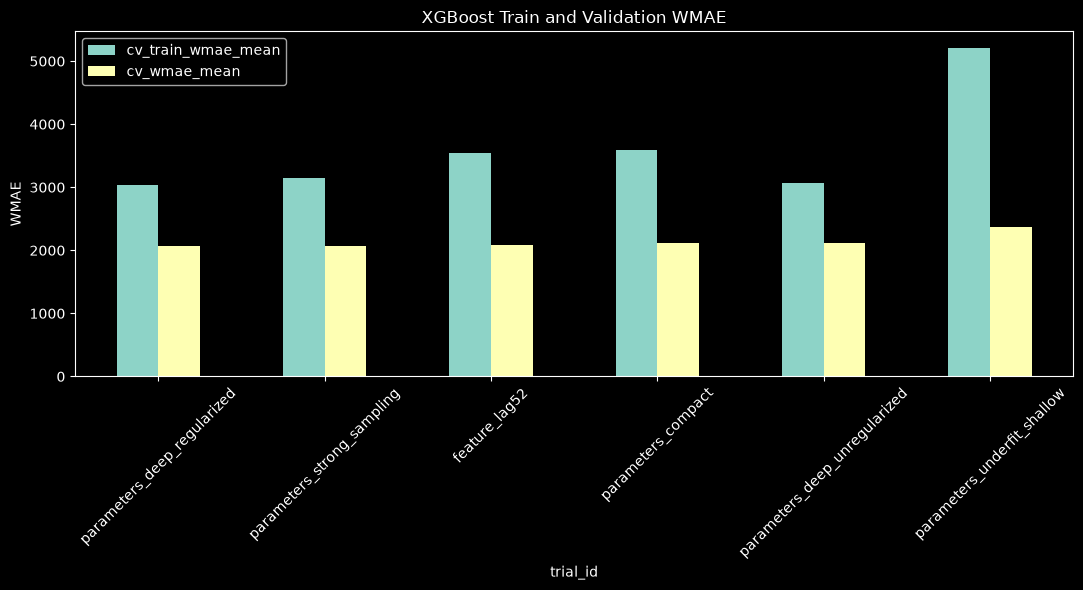

In [15]:
capacity_plot_data = (
    capacity_results[
        [
            "trial_id",
            "cv_train_wmae_mean",
            "cv_wmae_mean",
        ]
    ]
    .set_index("trial_id")
)

capacity_figure, capacity_axis = (
    plt.subplots(
        figsize=(11, 6)
    )
)

capacity_plot_data.plot.bar(
    ax=capacity_axis
)

capacity_axis.set_title(
    "XGBoost Train and Validation WMAE"
)

capacity_axis.set_ylabel(
    "WMAE"
)

capacity_axis.tick_params(
    axis="x",
    rotation=45,
)

capacity_figure.tight_layout()
plt.show()

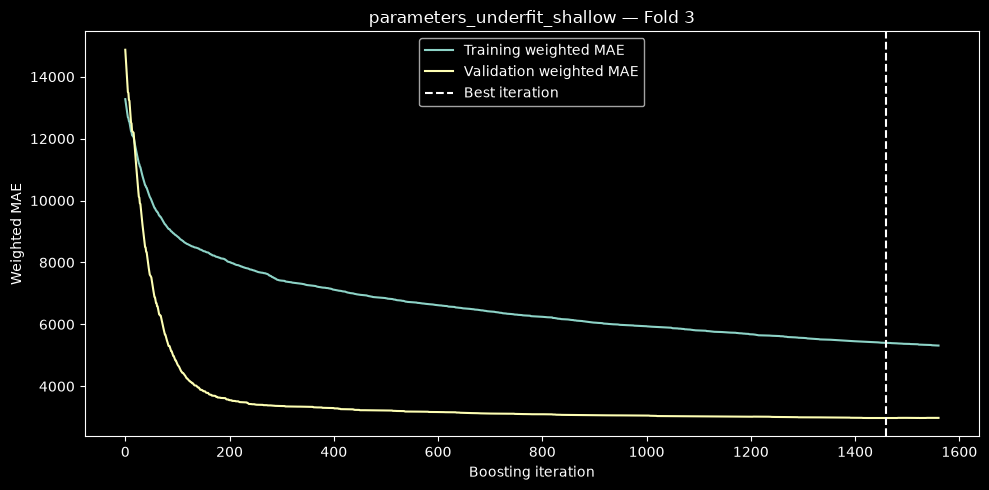

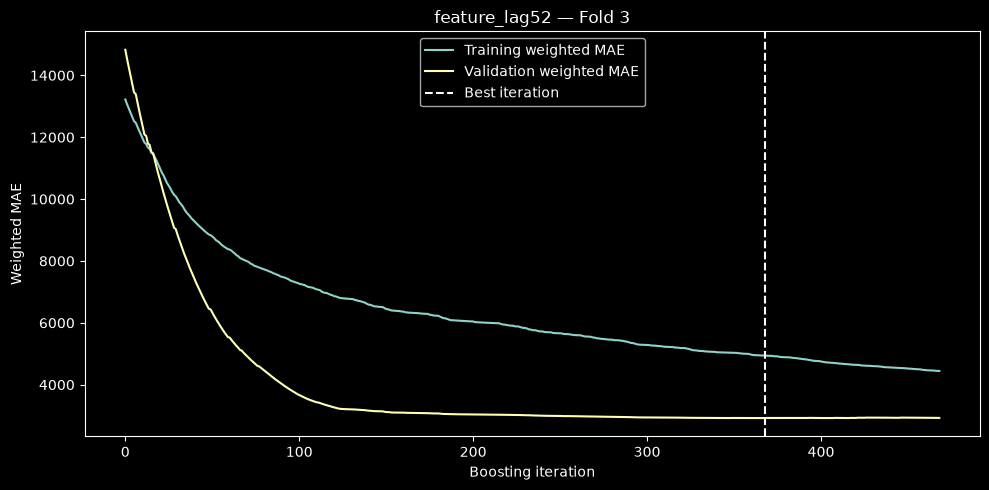

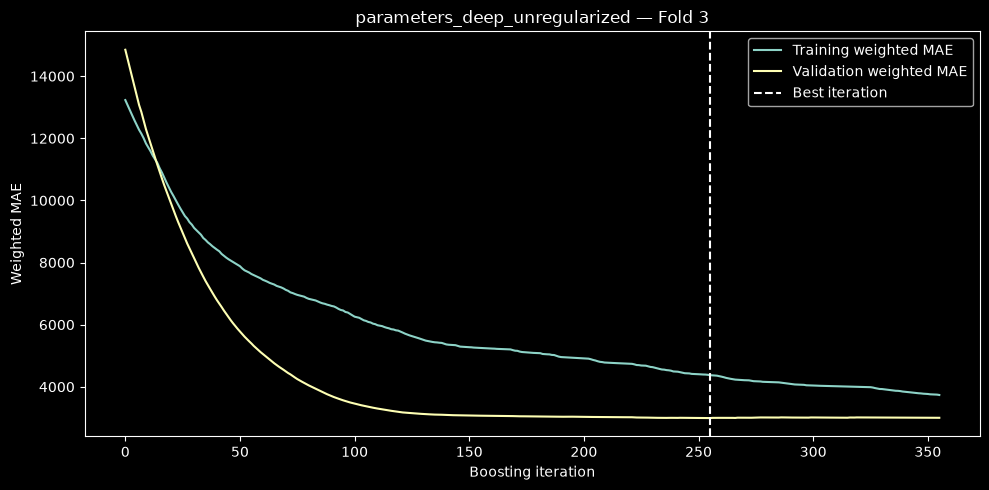

In [16]:
diagnostic_trial_ids = [
    "parameters_underfit_shallow",
    best_current_trial_id,
    "parameters_deep_unregularized",
]

diagnostic_fold = 3

learning_curve_figures = {}

for trial_id in diagnostic_trial_ids:
    history = (
        trial_learning_curves[
            trial_id
        ][diagnostic_fold]
    )

    train_curve = history[
        "validation_0"
    ]["mae"]

    validation_curve = history[
        "validation_1"
    ]["mae"]

    best_tree_count = int(
        trial_fold_results[
            trial_id
        ]
        .loc[
            lambda dataframe:
            dataframe["fold"]
            == diagnostic_fold,
            "best_n_estimators",
        ]
        .iloc[0]
    )

    figure, axis = plt.subplots(
        figsize=(10, 5)
    )

    axis.plot(
        train_curve,
        label="Training weighted MAE",
    )

    axis.plot(
        validation_curve,
        label="Validation weighted MAE",
    )

    axis.axvline(
        best_tree_count - 1,
        linestyle="--",
        label="Best iteration",
    )

    axis.set_title(
        f"{trial_id} — Fold "
        f"{diagnostic_fold}"
    )

    axis.set_xlabel(
        "Boosting iteration"
    )

    axis.set_ylabel(
        "Weighted MAE"
    )

    axis.legend()

    figure.tight_layout()
    plt.show()

    learning_curve_figures[
        trial_id
    ] = figure

## Final features

In [17]:
best_trial_id = (
    tuning_results.iloc[0][
        "trial_id"
    ]
)

best_trial = deepcopy(
    trial_registry[
        best_trial_id
    ]
)

best_trial_folds = (
    trial_fold_results[
        best_trial_id
    ]
)

final_n_estimators = int(
    np.median(
        best_trial_folds[
            "best_n_estimators"
        ]
    )
)

print(
    "Selected trial:",
    best_trial_id,
)

print(
    "Selected feature set:",
    best_trial["feature_set"],
)

print(
    "Selected preprocessing:",
    best_trial["preprocessing"],
)

print(
    "Selected capacity profile:",
    best_trial["capacity_profile"],
)

print(
    "Final n_estimators:",
    final_n_estimators,
)

tuning_results.head(10)

Selected trial: parameters_deep_regularized
Selected feature set: core_calendar_lag52_v1
Selected preprocessing: tree_markdown_zero_economic_median_ohe_v1
Selected capacity profile: deep_regularized
Final n_estimators: 890


,trial_id,trial_name,capacity_profile,feature_set,preprocessing,lags,include_economic,markdown_strategy,cv_train_wmae_mean,cv_wmae_mean,cv_wmae_std,cv_generalization_gap_mean,cv_generalization_gap_std,cv_mae_mean,cv_rmse_mean,best_n_estimators_median,lag_coverage_mean,fit_seconds,predict_seconds
0,parameters_deep_regularized,deep_regularized,deep_regularized,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"3,042.7099","2,073.0701",600.1492,-969.6398,268.0131,"1,889.9697","5,202.6642",890,0.9694,291.9071,2.3727
1,parameters_strong_sampling,strong_sampling,strong_sampling,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"3,153.1305","2,074.9147",593.8496,"-1,078.2158",398.7769,"1,900.8179","5,102.4980",1225,0.9694,433.5480,2.7474
2,preprocessing_markdown_median,markdown_median,balanced,core_calendar_lag52_v1,tree_markdown_median_economic_median_ohe_v1,"(52,)",True,median,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",436.9669,"1,908.3286","5,287.0361",1339,0.9694,303.8915,2.4707
3,feature_lag52,lag52,balanced,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"3,548.5172","2,082.9957",596.8303,"-1,465.5215",436.9669,"1,908.3286","5,287.0361",1339,0.9694,324.8976,2.5472
4,feature_lag52_no_economic,lag52_no_economic,balanced,core_calendar_lag52_no_economic_v1,tree_markdown_zero_no_economic_ohe_v1,"(52,)",False,zero,"3,336.2472","2,092.4324",588.0083,"-1,243.8148",418.5050,"1,913.4805","5,289.6007",1165,0.9694,335.5117,2.8651
5,parameters_compact,compact,compact,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"3,591.9486","2,108.5335",584.5775,"-1,483.4151",243.8076,"1,932.7671","5,224.6933",1948,0.9694,536.0477,2.9996
6,parameters_deep_unregularized,deep_unregularized,deep_unregularized,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"3,075.0903","2,122.2920",621.4772,-952.7983,589.8119,"1,938.3811","5,448.7273",608,0.9694,292.5623,2.7933
7,parameters_underfit_shallow,underfit_shallow,underfit_shallow,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,"(52,)",True,zero,"5,212.4920","2,372.7374",429.5372,"-2,839.7546",339.7005,"2,200.1617","5,761.1818",2155,0.9694,479.2038,1.7149
8,feature_core,core,balanced,core_calendar_v1,tree_markdown_zero_economic_median_ohe_v1,(),True,zero,"1,854.4627","2,649.1612",643.5892,794.6985,657.5255,"2,518.7642","6,268.8516",3000,NaN,852.5290,6.0155


In [18]:
development_rows, development_features = (
    prepare_features(
        rows=final_split.train,
        history=final_split.train,
        lags=best_trial["lags"],
    )
)

holdout_rows, holdout_features = (
    prepare_features(
        rows=final_split.validation,
        history=final_split.train,
        lags=best_trial["lags"],
    )
)

extra_numeric_columns = []

for lag in best_trial["lags"]:
    extra_numeric_columns.extend(
        [
            f"lag_{lag}",
            f"lag_{lag}_missing",
        ]
    )

final_preprocessor = (
    build_tree_preprocessor(
        extra_numeric_columns=(
            extra_numeric_columns
        ),
        include_economic=best_trial[
            "include_economic"
        ],
        markdown_strategy=best_trial[
            "markdown_strategy"
        ],
    )
)

x_development = (
    final_preprocessor.fit_transform(
        development_features
    )
)

x_holdout = (
    final_preprocessor.transform(
        holdout_features
    )
)

print(
    "Development matrix:",
    x_development.shape,
)

print(
    "Holdout matrix:",
    x_holdout.shape,
)

Development matrix: (305982, 153)
Holdout matrix: (115588, 153)


## Train

In [19]:
final_parameters = deepcopy(
    best_trial["parameters"]
)

final_parameters[
    "n_estimators"
] = final_n_estimators

final_model = XGBRegressor(
    objective="reg:absoluteerror",
    eval_metric="mae",
    tree_method="hist",
    random_state=(
        DEFAULT_RANDOM_SEED
    ),
    n_jobs=-1,
    verbosity=0,
    importance_type="gain",
    **final_parameters,
)

fit_start = time.perf_counter()

final_model.fit(
    x_development,
    development_rows[
        "Weekly_Sales"
    ].to_numpy(),
    sample_weight=(
        make_sample_weights(
            development_rows
        )
    ),
    verbose=False,
)

final_fit_seconds = (
    time.perf_counter()
    - fit_start
)

predict_start = time.perf_counter()

development_predictions = (
    final_model.predict(
        x_development
    )
)

holdout_predictions = (
    final_model.predict(
        x_holdout
    )
)

final_predict_seconds = (
    time.perf_counter()
    - predict_start
)

development_metrics = (
    evaluate_predictions(
        rows=development_rows,
        predictions=(
            development_predictions
        ),
    )
)

holdout_metrics = (
    evaluate_predictions(
        rows=holdout_rows,
        predictions=(
            holdout_predictions
        ),
    )
)

final_generalization_gap = (
    holdout_metrics["wmae"]
    - development_metrics["wmae"]
)

print(
    "Development WMAE:",
    development_metrics["wmae"],
)

print(
    "Holdout WMAE:",
    holdout_metrics["wmae"],
)

print(
    "Final generalization gap:",
    final_generalization_gap,
)

Development WMAE: 2611.3226774410255
Holdout WMAE: 1745.812314469766
Final generalization gap: -865.5103629712594


## Holdout prediction diagnostics

In [20]:
holdout_prediction_frame = (
    holdout_rows[
        [
            "Store",
            "Dept",
            "Date",
            "Weekly_Sales",
            "IsHoliday",
        ]
    ]
    .copy()
)

holdout_prediction_frame[
    "Prediction"
] = holdout_predictions

holdout_prediction_frame[
    "AbsoluteError"
] = (
    holdout_prediction_frame[
        "Weekly_Sales"
    ]
    - holdout_prediction_frame[
        "Prediction"
    ]
).abs()

holdout_prediction_frame.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Prediction,AbsoluteError
0,1,1,2012-02-03,"23,510.4900",False,"20,865.4199","2,645.0701"
1,1,2,2012-02-03,"54,322.2400",False,"47,836.2539","6,485.9861"
2,1,3,2012-02-03,"12,485.7800",False,"11,187.9521","1,297.8279"
3,1,4,2012-02-03,"40,274.8300",False,"37,459.2578","2,815.5722"
4,1,5,2012-02-03,"28,307.4300",False,"29,242.7246",935.2946


In [21]:
holiday_diagnostics = (
    holdout_prediction_frame
    .groupby("IsHoliday")
    .agg(
        rows=(
            "Prediction",
            "size",
        ),
        mean_actual=(
            "Weekly_Sales",
            "mean",
        ),
        mean_prediction=(
            "Prediction",
            "mean",
        ),
        mean_absolute_error=(
            "AbsoluteError",
            "mean",
        ),
    )
)

holiday_diagnostics

,rows,mean_actual,mean_prediction,mean_absolute_error
IsHoliday,,,,
False,109621,"15,808.0926","15,476.2910","1,739.0915"
True,5967,"16,480.5543","15,844.0195","1,770.5061"


In [22]:
department_diagnostics = (
    holdout_prediction_frame
    .groupby("Dept")
    .agg(
        rows=(
            "Prediction",
            "size",
        ),
        mean_absolute_error=(
            "AbsoluteError",
            "mean",
        ),
        total_absolute_error=(
            "AbsoluteError",
            "sum",
        ),
    )
    .sort_values(
        "total_absolute_error",
        ascending=False,
    )
)

department_diagnostics.head(15)

,rows,mean_absolute_error,total_absolute_error
Dept,,,
38,1755,"7,130.2343","12,513,561.1345"
92,1755,"6,641.5779","11,655,969.1296"
72,1656,"6,276.1532","10,393,309.7065"
95,1755,"5,299.6336","9,300,856.9913"
1,1755,"4,122.6268","7,235,210.0610"
90,1755,"3,772.0535","6,619,953.8441"
16,1755,"3,254.4643","5,711,584.7738"
7,1755,"3,189.7474","5,598,006.7282"
40,1755,"3,027.6886","5,313,593.5714"


## Feature Importance

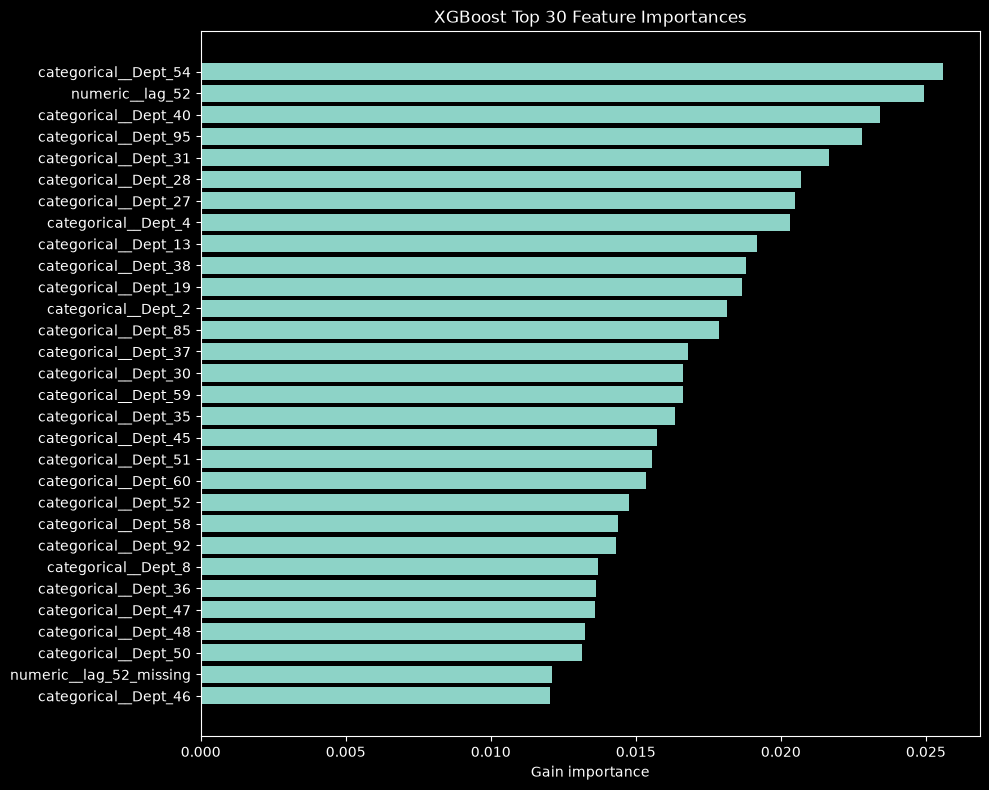

,feature,importance
0,categorical__Dept_54,0.0256
1,numeric__lag_52,0.0249
2,categorical__Dept_40,0.0234
3,categorical__Dept_95,0.0228
4,categorical__Dept_31,0.0217
5,categorical__Dept_28,0.0207
6,categorical__Dept_27,0.0205
7,categorical__Dept_4,0.0203
8,categorical__Dept_13,0.0192
9,categorical__Dept_38,0.0188


In [23]:
feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

feature_importance = (
    pd.DataFrame(
        {
            "feature": (
                feature_names
            ),
            "importance": (
                final_model
                .feature_importances_
            ),
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

top_features = (
    feature_importance
    .head(30)
)

importance_figure, importance_axis = (
    plt.subplots(
        figsize=(10, 8)
    )
)

importance_axis.barh(
    top_features[
        "feature"
    ][::-1],
    top_features[
        "importance"
    ][::-1],
)

importance_axis.set_title(
    "XGBoost Top 30 Feature Importances"
)

importance_axis.set_xlabel(
    "Gain importance"
)

importance_figure.tight_layout()
plt.show()

top_features

In [ ]:
## Final pipeline

In [24]:
final_pipeline = Pipeline(
    steps=[
        (
            "preprocessing",
            final_preprocessor,
        ),
        (
            "model",
            final_model,
        ),
    ]
)

pipeline_predictions = (
    final_pipeline.predict(
        holdout_features.head(100)
    )
)

direct_predictions = (
    final_model.predict(
        x_holdout[:100]
    )
)

np.testing.assert_allclose(
    pipeline_predictions,
    direct_predictions,
    rtol=1e-6,
    atol=1e-6,
)

print(
    "Pipeline prediction check passed."
)

Pipeline prediction check passed.


In [ ]:
## Final mlflow logging

In [25]:
best_cv_result = (
    tuning_results.iloc[0]
)

final_metrics = {
    "cv_wmae_mean": float(
        best_cv_result[
            "cv_wmae_mean"
        ]
    ),
    "cv_wmae_std": float(
        best_cv_result[
            "cv_wmae_std"
        ]
    ),
    "holdout_wmae": float(
        holdout_metrics[
            "wmae"
        ]
    ),
    "holdout_mae": float(
        holdout_metrics[
            "mae"
        ]
    ),
    "holdout_rmse": float(
        holdout_metrics[
            "rmse"
        ]
    ),
}

final_run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage="final",
    feature_set=best_trial[
        "feature_set"
    ],
    trial_name="best",
)

final_parameters_for_logging = (
    build_common_parameters(
        architecture=ARCHITECTURE,
        stage="final",
        feature_set=best_trial[
            "feature_set"
        ],
        preprocessing=best_trial[
            "preprocessing"
        ],
        evaluation_scope=(
            "full_dataset"
        ),
        forecast_strategy=(
            "global_tabular"
        ),
        series_count=series_count,
        extra_parameters={
            **final_parameters,
            "objective": (
                "reg:absoluteerror"
            ),
            "eval_metric": "mae",
            "tree_method": "hist",
            "lags": list(
                best_trial["lags"]
            ),
            "include_economic": (
                best_trial[
                    "include_economic"
                ]
            ),
            "markdown_strategy": (
                best_trial[
                    "markdown_strategy"
                ]
            ),
            "capacity_profile": (
                best_trial[
                    "capacity_profile"
                ]
            ),
            "selected_trial_id": (
                best_trial_id
            ),
        },
    )
)

final_run_name

'xgboost__final__core_calendar_lag52_v1__best__s42'

In [26]:
input_example = (
    holdout_features
    .head(10)
    .copy()
)

input_example_predictions = (
    final_pipeline.predict(
        input_example
    )
)

model_signature = infer_signature(
    model_input=input_example,
    model_output=(
        input_example_predictions
    ),
)

model_info = None

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=final_run_name,
    parameters=(
        final_parameters_for_logging
    ),
    tags={
        "architecture": (
            ARCHITECTURE
        ),
        "stage": "final",
        "scope": "full_dataset",
        "selected_trial_id": (
            best_trial_id
        ),
    },
):
    mlflow.log_metrics(
        {
            **final_metrics,
            "development_wmae": (
                development_metrics[
                    "wmae"
                ]
            ),
            "final_generalization_gap": (
                final_generalization_gap
            ),
            "fit_seconds": (
                final_fit_seconds
            ),
            "predict_seconds": (
                final_predict_seconds
            ),
            "final_n_estimators": (
                final_n_estimators
            ),
            "cv_train_wmae_mean": (
                best_cv_result[
                    "cv_train_wmae_mean"
                ]
            ),
            "cv_generalization_gap_mean": (
                best_cv_result[
                    "cv_generalization_gap_mean"
                ]
            ),
        }
    )

    model_info = mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        name="model",
        input_example=input_example,
        signature=model_signature,
        serialization_format=(
            "cloudpickle"
        ),
    )

    mlflow.log_dict(
        {
            "holdout_metrics": (
                final_metrics
            )
        },
        "evaluation/final_metrics.json",
    )

    with TemporaryDirectory() as (
        temporary_directory
    ):
        temporary_path = Path(
            temporary_directory
        )

        tuning_results.to_csv(
            temporary_path
            / "tuning_results.csv",
            index=False,
        )

        capacity_results.to_csv(
            temporary_path
            / "capacity_results.csv",
            index=False,
        )

        best_trial_folds.to_csv(
            temporary_path
            / "best_trial_folds.csv",
            index=False,
        )

        holdout_prediction_frame.to_csv(
            temporary_path
            / "holdout_predictions.csv",
            index=False,
        )

        feature_importance.to_csv(
            temporary_path
            / "feature_importance.csv",
            index=False,
        )

        holiday_diagnostics.to_csv(
            temporary_path
            / "holiday_diagnostics.csv",
        )

        department_diagnostics.to_csv(
            temporary_path
            / "department_diagnostics.csv",
        )

        mlflow.log_artifacts(
            str(temporary_path),
            artifact_path="evaluation",
        )

    mlflow.log_figure(
        capacity_figure,
        "evaluation/"
        "capacity_comparison.png",
    )

    mlflow.log_figure(
        importance_figure,
        "evaluation/"
        "feature_importance.png",
    )

    for trial_id, figure in (
        learning_curve_figures.items()
    ):
        mlflow.log_figure(
            figure,
            "evaluation/"
            f"learning_curve_{trial_id}.png",
        )

print(
    "Logged final run:",
    final_run_name,
)

print(
    "Model URI:",
    model_info.model_uri,
)

print(final_metrics)

/home/xizusha/Documents/ML/walmart-store-sales-forecasting/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/09 18:28:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run xgboost__final__core_calendar_lag52_v1__best__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6/runs/e8123053a1294ee3a87546557f12fe61
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/6
Logged final run: xgboost__final__core_calendar_lag52_v1__best__s42
Model URI: models:/m-1b3c87d72918456d8c7a116029c10949
{'cv_wmae_mean': 2073.070075642014, 'cv_wmae_std': 600.1492246188649, 'holdout_wmae': 1745.812314469766, 'holdout_mae': 1740.7132516878612, 'holdout_rmse': 3720.5687137380296}


In [27]:
loaded_model = mlflow.pyfunc.load_model(
    model_info.model_uri
)

loaded_predictions = (
    loaded_model.predict(
        input_example
    )
)

np.testing.assert_allclose(
    np.asarray(
        loaded_predictions
    ),
    np.asarray(
        input_example_predictions
    ),
    rtol=1e-6,
    atol=1e-6,
)

print(
    "Logged model reload check passed."
)

Logged model reload check passed.


## Save result

In [28]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=final_run_name,
    stage="final",
    tracker="mlflow",
    feature_set=best_trial[
        "feature_set"
    ],
    preprocessing=best_trial[
        "preprocessing"
    ],
    evaluation_scope=(
        "full_dataset"
    ),
    forecast_strategy=(
        "global_tabular"
    ),
    series_count=series_count,
    metrics=final_metrics,
    fit_seconds=(
        final_fit_seconds
    ),
    predict_seconds=(
        final_predict_seconds
    ),
    notes=(
        "Configuration selected by "
        "mean CV WMAE. Underfitting "
        "and overfitting assessed using "
        "training-validation gaps."
    ),
)

save_architecture_result(
    result_row
)

pd.DataFrame(
    [result_row]
)

,architecture,run_name,stage,tracker,feature_set,preprocessing,validation_id,data_version,evaluation_scope,forecast_strategy,series_count,random_seed,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds,notes
0,xgboost,xgboost__final__core_calendar_lag52_v1__best__s42,final,mlflow,core_calendar_lag52_v1,tree_markdown_zero_economic_median_ohe_v1,expanding_3x13_holdout_39_v1,processed_v1,full_dataset,global_tabular,3306,42,"2,073.0701",600.1492,"1,745.8123","1,740.7133","3,720.5687",105.1422,1.2715,Configuration selected by mean CV WMAE. Underf...


## Compare tree models so far

In [34]:
from walmart_forecasting.paths import TABLES_DIR


lightgbm_path = (
    TABLES_DIR
    / "lightgbm_final.csv"
)

xgboost_path = (
    TABLES_DIR
    / "xgboost_final.csv"
)

comparison_frames = []

for result_path in [
    lightgbm_path,
    xgboost_path,
]:
    if result_path.exists():
        comparison_frames.append(
            pd.read_csv(result_path)
        )

if comparison_frames:
    tree_model_comparison = (
        pd.concat(
            comparison_frames,
            ignore_index=True,
        )
        .sort_values(
            "holdout_wmae"
        )
        .reset_index(drop=True)
    )

    tree_model_comparison = (
        tree_model_comparison[
            [
                "architecture",
                "feature_set",
                "cv_wmae_mean",
                "cv_wmae_std",
                "holdout_wmae",
                "holdout_mae",
                "holdout_rmse",
                "fit_seconds",
                "predict_seconds",
            ]
        ]
    )
else:
    tree_model_comparison = pd.DataFrame(
        columns=[
            "architecture",
            "feature_set",
            "cv_wmae_mean",
            "cv_wmae_std",
            "holdout_wmae",
            "holdout_mae",
            "holdout_rmse",
            "fit_seconds",
            "predict_seconds",
        ]
    )

tree_model_comparison

,architecture,feature_set,cv_wmae_mean,cv_wmae_std,holdout_wmae,holdout_mae,holdout_rmse,fit_seconds,predict_seconds
0,lightgbm,core_calendar_lag52_v1,"1,949.1676",497.7775,"1,707.1122","1,713.6278","3,646.4237",29.4280,0.6944
1,xgboost,core_calendar_lag52_v1,"2,073.0701",600.1492,"1,745.8123","1,740.7133","3,720.5687",105.1422,1.2715
